In [1]:
import pandas as pd
import re
import nltk
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def cargar_datos(file_path):
    df = pd.read_csv(file_path)
    return df


def EDA(df):
    rosa_principal = "#FF85A2" 
    print(df.head())
    print(df["sentiment"].value_counts())
    print(df["review"].iloc[0])
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df["sentiment"], color=rosa_principal, edgecolor="black") 
    plt.title("Distribución de Sentimiento",fontsize=14, color="#AD1457")
    plt.xlabel("Clases")
    plt.ylabel("Número de muestras")
    sns.despine()
    plt.show()

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"[^a-záéíóúñü ]", "", texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    return " ".join(palabras)

def preprocesar(df):
    df["review_limpia"] = df["review"].apply(limpiar_texto)
    onehot = OneHotEncoder(sparse_output=False, drop="first")
    dummies = onehot.fit_transform(df[["sentiment"]])
    dummies_df = pd.DataFrame(dummies, columns=onehot.get_feature_names_out(["sentiment"]), index=df.index)
    df = pd.concat([df, dummies_df], axis=1)
    print(df.columns)
    return df

def vectorizar_texto(df):
    vectorizador = CountVectorizer(max_features=3000)
    X = vectorizador.fit_transform(df["review_limpia"])
    y = df["sentiment"]
    return X, y, vectorizador

def division_de_datos(X,y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    return X_train, X_test, y_train, y_test

def entrenar_modelo(X_train, y_train):
    modelo = MultinomialNB()
    modelo.fit(X_train, y_train)    
    return modelo

def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        display_labels=['Negativo', 'Positivo'],
        cmap=plt.cm.Blues
    )
    plt.title('Matriz de Confusión', fontsize=14, color="#AD1457")
    plt.xlabel('Etiqueta Predicha', color="#AD1457")
    plt.ylabel('Etiqueta Real', color="#AD1457")
    
    plt.show()
    print(classification_report(y_test, y_pred))

def prueba(modelo, vectorizador, texto):
    texto_limpio = limpiar_texto(texto)
    texto_vectorizado = vectorizador.transform([texto_limpio])
    prediccion = modelo.predict(texto_vectorizado)
    return prediccion[0]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marcela/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maxim

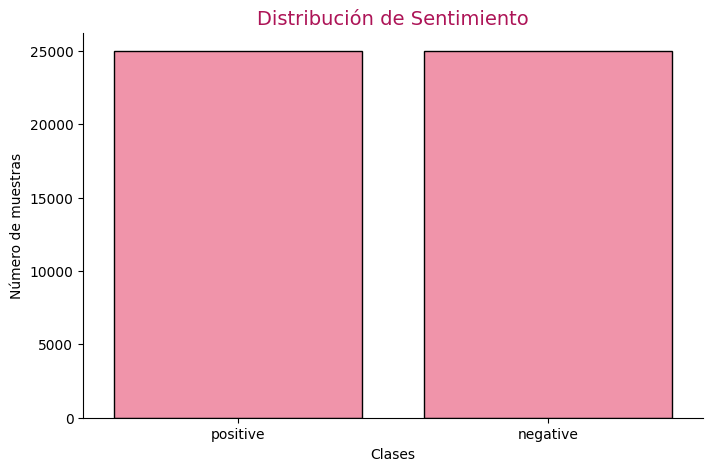

In [6]:
df = cargar_datos('./IMDB Dataset.csv')
EDA(df)

In [7]:
df = preprocesar(df)
X, y, mi_vectorizador = vectorizar_texto(df) 
X_train, X_test, y_train, y_test = division_de_datos(X, y)
modelo = entrenar_modelo(X_train, y_train)

Index(['review', 'sentiment', 'review_limpia', 'sentiment_positive'], dtype='str')


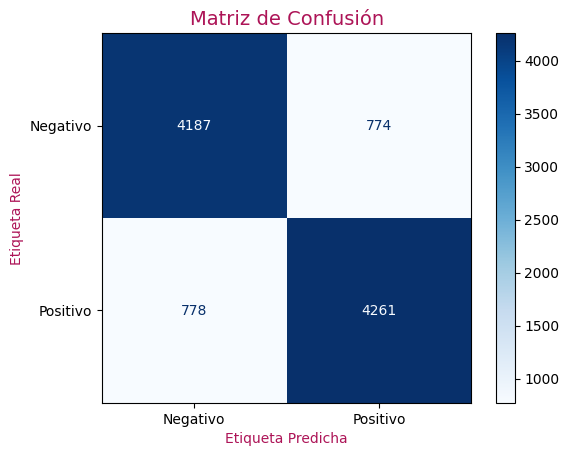

              precision    recall  f1-score   support

    negative       0.84      0.84      0.84      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [8]:
evaluar_modelo(modelo, X_test, y_test)

In [9]:
prueba_texto = "This movie was fantastic! I loved it."
nuevo_limpio = limpiar_texto(prueba_texto) 
vector = mi_vectorizador.transform([nuevo_limpio]) 
resultado = modelo.predict(vector)
print(f"Resultado: {resultado[0]}")

Resultado: positive


In [10]:
prueba_texto_negativo = "This movie was terrible. I hated it."
nuevo_limpio_negativo = limpiar_texto(prueba_texto_negativo)
vector_negativo = mi_vectorizador.transform([nuevo_limpio_negativo])
resultado_negativo = modelo.predict(vector_negativo)
print(f"Resultado: {resultado_negativo[0]}")

Resultado: negative


In [11]:
prueba_texto_positivo = "The movie was very good, I liked how the actores performed."
nuevo_limpio_positivo = limpiar_texto(prueba_texto_positivo)
vector_positivo = mi_vectorizador.transform([nuevo_limpio_positivo])
resultado_positivo = modelo.predict(vector_positivo)
print(f"Resultado: {resultado_positivo[0]}")

Resultado: positive
